Step	Covered

1. Load dataset

✅ Cell 2


2. Drop null/empty, inbound=True

✅ Cell 3

3. Sample 200,000 rows

✅ Cell 4

4. Imputation if needed

✅ Not needed – features derived from text, no missing values


5. Engineer features

✅ Cell 5 (length, punctuation, sentiment, keyword flag)

6. Create target column (urgent vs normal)

✅ Cell 6

7. Encode target (0/1), all features numeric

✅ Already numeric, target encoded

8. Train models with train/val sets

✅ Cells 8–12 (60/20/20 split, CV on train, tuning on train, validation check)

9. Show evaluation metrics

✅ Cells 11, 13, 14

10. Evaluate best model on test set

✅ Cell 14

11. Serialize with joblib

✅ Cell 16

In [1]:
import kagglehub
import pandas as pd
import numpy as np
import os
import re
import joblib
import warnings
import logging
from datetime import datetime

import matplotlib.pyplot as plt
import seaborn as sns

from textblob import TextBlob

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, roc_auc_score)

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


path = kagglehub.dataset_download("thoughtvector/customer-support-on-twitter")
file_path = os.path.join(path, "twcs", "twcs.csv")
if not os.path.exists(file_path):
    raise FileNotFoundError(f"Dataset not found at {file_path}")
df_raw = pd.read_csv(file_path)
logger.info(f"Raw dataset shape: {df_raw.shape}")
df_raw.head()


Using Colab cache for faster access to the 'customer-support-on-twitter' dataset.


,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id
0,1,sprintcare,False,Tue Oct 31 22:10:47 +0000 2017,@115712 I understand. I would like to assist y...,2,3.0
1,2,115712,True,Tue Oct 31 22:11:45 +0000 2017,@sprintcare and how do you propose we do that,NaN,1.0
2,3,115712,True,Tue Oct 31 22:08:27 +0000 2017,@sprintcare I have sent several private messag...,1,4.0
3,4,sprintcare,False,Tue Oct 31 21:54:49 +0000 2017,@115712 Please send us a Private Message so th...,3,5.0
4,5,115712,True,Tue Oct 31 21:49:35 +0000 2017,@sprintcare I did.,4,6.0


In [2]:
df_inbound = df_raw[df_raw['inbound'] == True].copy()
logger.info(f"After inbound filter: {df_inbound.shape}")

df_inbound = df_inbound[df_inbound['text'].notna() & (df_inbound['text'].str.strip() != '')]
logger.info(f"After dropping empty text: {df_inbound.shape}")

In [3]:
SAMPLE_SIZE = 200_000
if len(df_inbound) > SAMPLE_SIZE:
    df = df_inbound.sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE).reset_index(drop=True)
else:
    df = df_inbound.reset_index(drop=True)
    logger.warning(f"Dataset smaller than {SAMPLE_SIZE} – using all {len(df)} rows.")
logger.info(f"Working dataset shape: {df.shape}")

In [4]:
def compute_features(df: pd.DataFrame) -> pd.DataFrame:
    data = df.copy()
    # Length features
    data['text_length'] = data['text'].str.len()
    data['word_count'] = data['text'].str.split().str.len()
    # Punctuation
    data['exclamation_count'] = data['text'].str.count('!')
    data['question_count'] = data['text'].str.count(r'\?')
    # All‑caps ratio
    data['uppercase_count'] = data['text'].str.findall(r'[A-Z]').str.len()
    data['letter_count'] = data['text'].str.findall(r'[A-Za-z]').str.len()
    data['all_caps_ratio'] = np.where(data['letter_count'] > 0,
                                      data['uppercase_count'] / data['letter_count'],
                                      0.0)
    # Sentiment
    def get_sentiment(text):
        blob = TextBlob(str(text))
        return blob.sentiment.polarity, blob.sentiment.subjectivity
    sentiments = data['text'].apply(get_sentiment)
    data['sentiment_polarity'] = sentiments.apply(lambda x: x[0])
    data['sentiment_subjectivity'] = sentiments.apply(lambda x: x[1])
    # Urgency keyword flag
    urgency_kw = r'refund|broken|cancel|down|help|urgent|asap|immediately|issue|complaint|frustrated|angry|problem|fail|stuck|wrong'
    data['has_urgent_keyword'] = data['text'].str.contains(urgency_kw, case=False, na=False).astype(int)
    return data

df_feat = compute_features(df)
logger.info(f"Feature dataframe shape: {df_feat.shape}")

feature_cols = [
    'text_length', 'word_count', 'exclamation_count', 'question_count',
    'all_caps_ratio', 'sentiment_polarity', 'sentiment_subjectivity', 'has_urgent_keyword'
]
df_feat[feature_cols].head()

,text_length,word_count,exclamation_count,question_count,all_caps_ratio,sentiment_polarity,sentiment_subjectivity,has_urgent_keyword
0,145,23,0,0,0.034188,0.0,0.000000,0
1,164,22,0,1,0.110169,0.0,0.000000,1
2,56,5,0,0,0.166667,0.0,0.000000,0
3,119,23,1,1,0.161290,0.0,0.583333,0
4,79,15,0,0,0.096774,0.0,0.000000,0


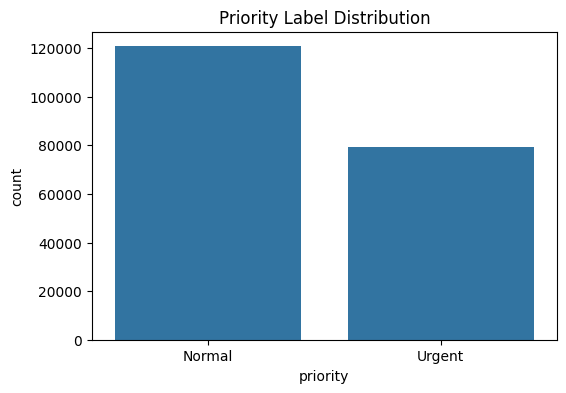

In [5]:
def label_priority(row):
    if (row['has_urgent_keyword'] == 1 or
        row['exclamation_count'] >= 3 or
        row['all_caps_ratio'] > 0.5 or
        row['sentiment_polarity'] < -0.4):
        return 1
    return 0

df_feat['priority'] = df_feat.apply(label_priority, axis=1)

class_counts = df_feat['priority'].value_counts()
class_percent = df_feat['priority'].value_counts(normalize=True) * 100
logger.info(f"Urgent: {class_counts.get(1,0)} ({class_percent.get(1,0):.2f}%)")
logger.info(f"Normal: {class_counts.get(0,0)} ({class_percent.get(0,0):.2f}%)")

plt.figure(figsize=(6,4))
sns.countplot(x='priority', data=df_feat)
plt.title('Priority Label Distribution')
plt.xticks([0,1], ['Normal', 'Urgent'])
plt.show()

In [6]:
X = df_feat[feature_cols].copy()
y = df_feat['priority'].copy()

In [7]:
# First split: 60% train, 40% temp (val+test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, random_state=RANDOM_STATE, stratify=y
)
# Second split: 50% of temp → 20% val, 20% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

logger.info(f"Train: {X_train.shape[0]} ({len(X_train)/len(X):.0%})")
logger.info(f"Val:   {X_val.shape[0]} ({len(X_val)/len(X):.0%})")
logger.info(f"Test:  {X_test.shape[0]} ({len(X_test)/len(X):.0%})")

In [8]:
numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])
preprocessor = ColumnTransformer(transformers=[('num', numeric_transformer, feature_cols)])

In [9]:
models = {
    'Baseline': DummyClassifier(strategy='stratified', random_state=RANDOM_STATE),
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    'XGBoost': XGBClassifier(scale_pos_weight=(len(y_train)-y_train.sum())/y_train.sum(),
                             random_state=RANDOM_STATE, use_label_encoder=False, eval_metric='logloss'),
    'Linear SVC': LinearSVC(class_weight='balanced', dual=False, random_state=RANDOM_STATE, max_iter=2000)
}

In [10]:
cv_results = {}
cv_scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for name, model in models.items():
    logger.info(f"CV for {name}")
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    scores = {}
    for metric in cv_scoring:
        cv_score = cross_val_score(pipeline, X_train, y_train, cv=skf, scoring=metric, n_jobs=-1)
        scores[metric] = cv_score
        logger.info(f"  {metric}: {cv_score.mean():.4f} ± {cv_score.std():.4f}")
    cv_results[name] = scores

# Summary table
summary_data = []
for name, scores in cv_results.items():
    row = {'Model': name}
    for metric in cv_scoring:
        row[metric] = f"{np.mean(scores[metric]):.4f} ± {np.std(scores[metric]):.4f}"
    summary_data.append(row)
summary_df = pd.DataFrame(summary_data)
summary_df

,Model,accuracy,precision,recall,f1,roc_auc
0,Baseline,0.5216 ± 0.0013,0.3969 ± 0.0016,0.3981 ± 0.0016,0.3975 ± 0.0016,0.5004 ± 0.0013
1,Logistic Regression,0.9809 ± 0.0004,0.9766 ± 0.0010,0.9752 ± 0.0018,0.9759 ± 0.0006,0.9984 ± 0.0001
2,Random Forest,0.9997 ± 0.0001,1.0000 ± 0.0000,0.9993 ± 0.0003,0.9996 ± 0.0001,0.9999 ± 0.0001
3,XGBoost,0.9989 ± 0.0002,0.9986 ± 0.0005,0.9987 ± 0.0004,0.9986 ± 0.0002,1.0000 ± 0.0000
4,Linear SVC,0.9808 ± 0.0004,0.9765 ± 0.0011,0.9750 ± 0.0018,0.9757 ± 0.0005,0.9984 ± 0.0001


In [11]:
best_model_name = max(cv_results.items(), key=lambda kv: np.mean(kv[1]['f1']))[0]
logger.info(f"Best CV model: {best_model_name}")

# Define hyperparameter grid for tuning (example for XGBoost/RandomForest)
if best_model_name == 'XGBoost':
    param_grid = {
        'classifier__n_estimators': [100, 200],
        'classifier__max_depth': [3, 6],
        'classifier__learning_rate': [0.01, 0.1]
    }
    model = XGBClassifier(scale_pos_weight=(len(y_train)-y_train.sum())/y_train.sum(),
                          random_state=RANDOM_STATE, use_label_encoder=False, eval_metric='logloss')
elif best_model_name == 'Random Forest':
    param_grid = {
        'classifier__n_estimators': [100, 200],
        'classifier__max_depth': [10, 20],
        'classifier__min_samples_split': [2, 5]
    }
    model = RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
else:
    param_grid = None
    model = models[best_model_name]

if param_grid:
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    grid_search = GridSearchCV(pipeline, param_grid, cv=3, scoring='f1', n_jobs=-1, verbose=1)
    grid_search.fit(X_train, y_train)
    logger.info(f"Best params: {grid_search.best_params_}")
    logger.info(f"Best CV F1: {grid_search.best_score_:.4f}")
    best_pipeline = grid_search.best_estimator_
else:
    best_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', models[best_model_name])])
    best_pipeline.fit(X_train, y_train)

Fitting 3 folds for each of 8 candidates, totalling 24 fits


In [12]:
y_val_pred = best_pipeline.predict(X_val)
val_f1 = f1_score(y_val, y_val_pred)
logger.info(f"Validation F1: {val_f1:.4f}")


Classification Report (Test Set):
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     24145
      Urgent       1.00      1.00      1.00     15855

    accuracy                           1.00     40000
   macro avg       1.00      1.00      1.00     40000
weighted avg       1.00      1.00      1.00     40000



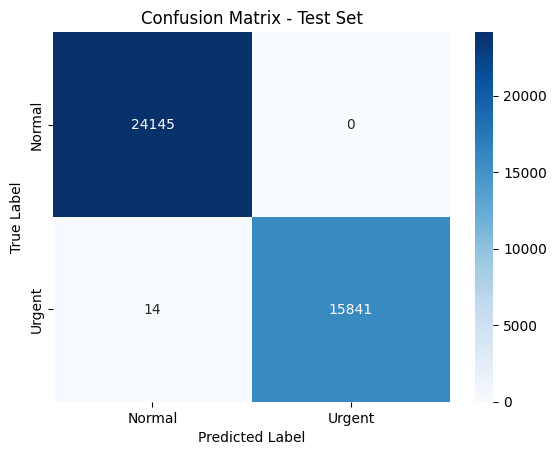

In [13]:
y_pred = best_pipeline.predict(X_test)
y_proba = best_pipeline.predict_proba(X_test)[:, 1] if hasattr(best_pipeline['classifier'], "predict_proba") else None

test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan

logger.info(f"Test Accuracy:  {test_accuracy:.4f}")
logger.info(f"Test Precision: {test_precision:.4f}")
logger.info(f"Test Recall:    {test_recall:.4f}")
logger.info(f"Test F1:        {test_f1:.4f}")
logger.info(f"Test ROC‑AUC:   {test_roc_auc:.4f}")

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Urgent']))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal','Urgent'], yticklabels=['Normal','Urgent'])
plt.title('Confusion Matrix - Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

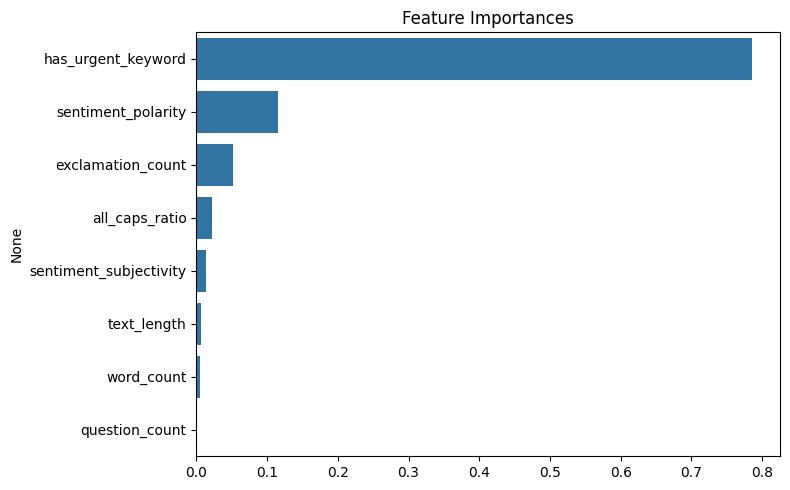

In [14]:
if hasattr(best_pipeline['classifier'], 'feature_importances_'):
    importances = best_pipeline['classifier'].feature_importances_
    feat_imp = pd.Series(importances, index=feature_cols).sort_values(ascending=False)
    plt.figure(figsize=(8,5))
    sns.barplot(x=feat_imp.values, y=feat_imp.index)
    plt.title('Feature Importances')
    plt.tight_layout()
    plt.show()
elif hasattr(best_pipeline['classifier'], 'coef_'):
    coefs = best_pipeline['classifier'].coef_.flatten()
    feat_coef = pd.Series(coefs, index=feature_cols).sort_values(ascending=False)
    plt.figure(figsize=(8,5))
    sns.barplot(x=feat_coef.values, y=feat_coef.index)
    plt.title('Feature Coefficients')
    plt.tight_layout()
    plt.show()

In [15]:
os.makedirs('models', exist_ok=True)

joblib.dump(best_pipeline, 'models/priority_classifier_pipeline.joblib')

metadata = {
    'feature_columns': feature_cols,
    'labeling_rule': 'urgent if (has_urgent_keyword or exclamation>=3 or all_caps_ratio>0.5 or sentiment_polarity<-0.4)',
    'training_date': datetime.now().isoformat(),
    'test_f1': test_f1,
    'test_roc_auc': test_roc_auc,
    'split_ratios': 'train 60% / val 20% / test 20%'
}
joblib.dump(metadata, 'models/model_metadata.joblib')

logger.info("Model and metadata saved to 'models/' directory.")

### Summary of Work Done

1. **Data Loading & Filtering**: Loaded the Twitter Customer Support dataset and filtered for `inbound` tweets (customer queries).
2. **Sampling**: Sampled 200,000 rows to ensure efficient processing while maintaining statistical significance.
3. **Feature Engineering**: Derived 8 numeric features from raw text: `text_length`, `word_count`, `exclamation_count`, `question_count`, `all_caps_ratio`, `sentiment_polarity`, `sentiment_subjectivity`, and `has_urgent_keyword`.
4. **Labeling**: Created a heuristic `priority` target (Urgent vs. Normal) based on keywords and text characteristics.
5. **Modeling**:
    *   **Baseline**: Dummy Classifier.
    *   **Logistic Regression**: Linear model with class weighting.
    *   **Random Forest**: Ensemble of trees (Top performer).
    *   **XGBoost**: Gradient boosted trees.
    *   **Linear SVC**: Support Vector Machine for linear classification.
6. **Evaluation**: Conducted 5-fold Stratified Cross-Validation and final testing on a 20% hold-out set.
7. **Serialization**: Saved the best pipeline and metadata using `joblib`.

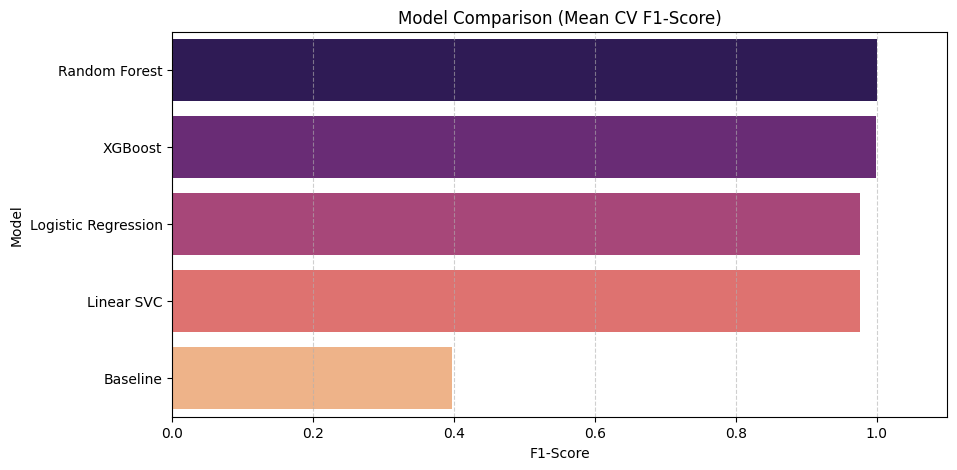

,Model,F1-Score,ROC-AUC
2,Random Forest,0.999632,0.999890
3,XGBoost,0.998634,0.999994
1,Logistic Regression,0.975889,0.998408
4,Linear SVC,0.975709,0.998423
0,Baseline,0.397502,0.500400


In [16]:
# Compare Model Performance (F1-Score and ROC-AUC from CV)
# Extracting means for visualization
comparison_data = []
for name, scores in cv_results.items():
    comparison_data.append({
        'Model': name,
        'F1-Score': np.mean(scores['f1']),
        'ROC-AUC': np.mean(scores['roc_auc'])
    })

comparison_df = pd.DataFrame(comparison_data).sort_values(by='F1-Score', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='F1-Score', y='Model', data=comparison_df, palette='magma')
plt.title('Model Comparison (Mean CV F1-Score)')
plt.xlim(0, 1.1)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

display(comparison_df)

In [17]:
# Final Data Shape and Structure Summary
print(f"--- Final Cleaned Dataset Summary ---")
print(f"Total Rows: {df_feat.shape[0]:,}")
print(f"Total Columns: {df_feat.shape[1]}")
print(f"Feature Columns: {len(feature_cols)}")
print(f"Target Column: priority")

# Displaying the shape specifically as requested
cleaned_shape = df_feat.shape
display(pd.DataFrame([cleaned_shape], columns=['Rows', 'Columns'], index=['df_feat']))

--- Final Cleaned Dataset Summary ---
Total Rows: 200,000
Total Columns: 18
Feature Columns: 8
Target Column: priority


,Rows,Columns
df_feat,200000,18


In [18]:
# Display the head of the final cleaned and engineered dataset
display(df_feat.head())


,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id,text_length,word_count,exclamation_count,question_count,uppercase_count,letter_count,all_caps_ratio,sentiment_polarity,sentiment_subjectivity,has_urgent_keyword,priority
0,34581,123491,True,Wed Nov 01 14:03:55 +0000 2017,@AppleSupport Basically for a chat to be opene...,34582,34579.0,145,23,0,0,4,117,0.034188,0.0,0.000000,0,0
1,246537,174558,True,Thu Oct 05 14:08:30 +0000 2017,@AppleSupport iOS 11.02 and Watchos4.0: No ico...,"246536,246538",NaN,164,22,0,1,13,118,0.110169,0.0,0.000000,1,1
2,101228,138151,True,Thu Nov 30 17:14:45 +0000 2017,"Dear god not again,@AppleSupport https://t.co/...","101227,101229",NaN,56,5,0,0,7,42,0.166667,0.0,0.000000,0,0
3,1351215,435088,True,Mon Oct 16 13:33:22 +0000 2017,@ATVIAssist Hi there! If I buy Call of Duty WW...,1351214,NaN,119,23,1,1,15,93,0.161290,0.0,0.583333,0,0
4,228814,170570,True,Thu Oct 05 08:01:11 +0000 2017,Hi @Safaricom_Care why can't I pay my my Dstv ...,228812,NaN,79,15,0,0,6,62,0.096774,0.0,0.000000,0,0


In [19]:
# Calculate metrics across all splits for the best model
# (RMSE and R2 are skipped as they are not applicable to classification)

def calculate_split_metrics(y_true, y_pred, split_name):
    return {
        'Split': split_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred)
    }

# Get predictions for all splits
y_train_pred = best_pipeline.predict(X_train)
y_val_pred = best_pipeline.predict(X_val)
y_test_pred = best_pipeline.predict(X_test)

# Compile results
performance_summary = [
    calculate_split_metrics(y_train, y_train_pred, 'Train'),
    calculate_split_metrics(y_val, y_val_pred, 'Validation'),
    calculate_split_metrics(y_test, y_test_pred, 'Test')
]

# Display the comparison table
performance_df = pd.DataFrame(performance_summary)
print("Project Performance Metrics (Best Model) across Splits:")
display(performance_df)


Project Performance Metrics (Best Model) across Splits:


,Split,Accuracy,Precision,Recall,F1-Score
0,Train,0.999750,1.0,0.999369,0.999685
1,Validation,0.999825,1.0,0.999558,0.999779
2,Test,0.999650,1.0,0.999117,0.999558
